---
# <center> **COMPUTER VISION** </center>
---
# <center>**Lab 4: Wavelet Transform**</center> 
---
## Table of Contents

1. **Setup and Libraries**

2. **Data Preparation**
    - 2.1 Dataset
    - 2.2 Preprocessing

3. **Wavelet Hash Generation**
    - 3.1 Wavelet Transform
    - 3.2 Quantization
    - 3.3 Hash Generation

4. **Hash Comparison**
    - 4.1 Hamming Distance
    <!-- - 4.2 Similarity Threshold -->

5. **Performance Evaluation**

6. **Advanced Experiments**
    - 6.1 Comparison of Different Wavelets
    - 6.2 Image Retrieval Demo

---
## 1. Setup and Libraries
---

- Installation command: 
`pip install numpy opencv-python matplotlib PyWavelets rembg`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import pywt

print(f"Pywavelet version: {pywt.__version__}")
print(f"OpenCV version: {cv2.__version__}")

Pywavelet version: 1.8.0
OpenCV version: 4.13.0


In [2]:
from pathlib import Path
import sys

root_path = str(Path().resolve().parent)

# Thêm đường dẫn gốc vào hệ thống tìm kiếm của Python
if root_path not in sys.path:
    sys.path.append(root_path)

---
## 2. Data Preparation
---
### 2.1 Dataset


* Sử dụng **Animals-10 Dataset** với **100 ảnh gốc** (10 loài, mỗi loài 10 ảnh).
* Tạo các ảnh biến đổi bằng cách thêm **Gaussian Noise** và **Rotation góc nhỏ** cho từng ảnh. => Tổng cộng 300 ảnh tất cả => 500 cặp


```text
                  ┌──> [Gốc A] + [Noise A]       (Label 1: Positive)
                  ├──> [Gốc A] + [Rotate A]      (Label 1: Positive)
                  │
[Ảnh Gốc A] ──────┼──> [Gốc A] + [Gốc B]         (Label 0: Negative)
                  ├──> [Gốc A] + [Noise B]       (Label 0: Negative)
                  └──> [Gốc A] + [Rotate B]      (Label 0: Negative)

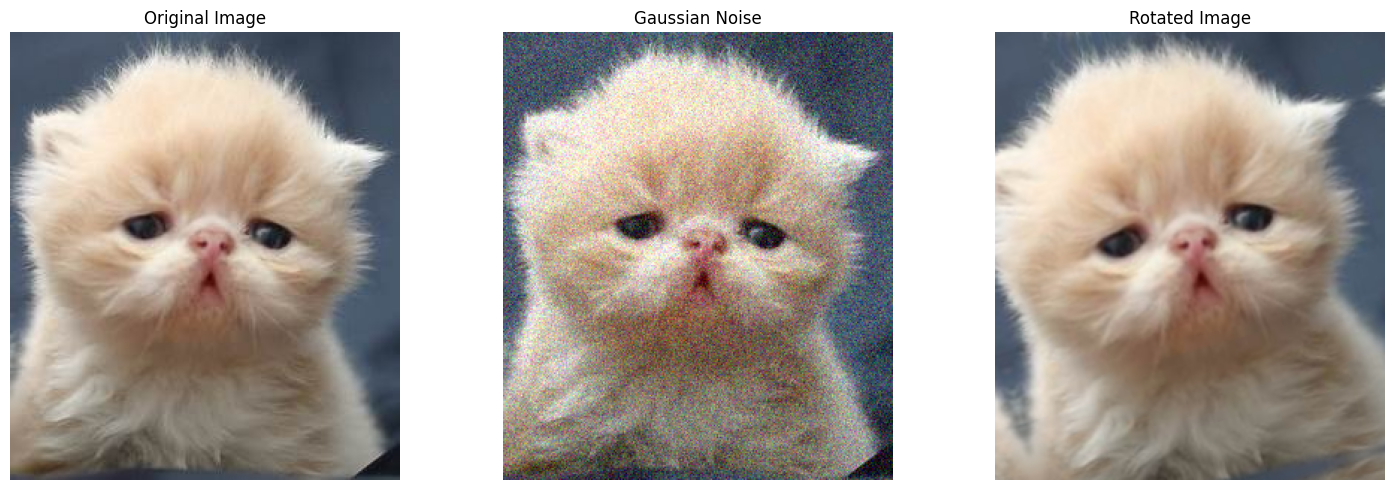

In [3]:
from src.add_gaussian_noise import add_gaussian_noise
from src.rotate_image import rotate_and_crop

# Apply noise Gaussian and rotation
original_image = cv2.imread('../assets/demo/img_1.png')
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)                                                                        # type: ignore  
noise_img = add_gaussian_noise(original_image)
rotated_img = rotate_and_crop(original_image, angle_range=[15.0, 20.0])                                                                 # type: ignore

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Original Image
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Plot Noisy Image
axes[1].imshow(noise_img)
axes[1].set_title("Gaussian Noise")
axes[1].axis("off")

# Plot Rotated Image
axes[2].imshow(rotated_img)
axes[2].set_title("Rotated Image")
axes[2].axis("off")

# Adjust spacing and display
plt.tight_layout()
plt.show()

---

### 2.2 Preprocessing
---

In [4]:
from rembg import remove

def preprocess_image(image, image_size=128, color_space=cv2.COLOR_BGR2GRAY, remove_background=False):
    """
    Preprocess image by removing background, resizing, and converting color space.

    Args:
        image (numpy.ndarray): Input image array (BGR/RGB).
        image_size (int): Target size for square resizing. Defaults to 128.
        color_space (int): Target OpenCV color conversion code. Defaults to cv2.COLOR_BGR2GRAY.

    Returns:
        numpy.ndarray: Preprocessed grayscale image.
    """
    # Remove background
    if remove_background:
        nobg_img = remove(image)
    else:
        nobg_img = image
    
    # Resize to squares
    resized_img = cv2.resize(nobg_img, (image_size, image_size))                        # type: ignore                        
    
    # Convert to grayscale based on channels
    if len(resized_img.shape) == 3 and resized_img.shape == 4:
        processed_img = cv2.cvtColor(resized_img, cv2.COLOR_BGRA2GRAY)
    else:
        processed_img = cv2.cvtColor(resized_img, color_space)
    
    return processed_img

/home/anle/Documents/course/CV/cv-coursework-labs/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Đọc ảnh gốc
original_image = cv2.imread("../assets/demo/dog_1.png")
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)                                                # type: ignore

# Tạo ảnh nhiễu
noise_image = add_gaussian_noise(image=original_image)

# Preprocess
processed_original = preprocess_image(image=original_image)
processed_noise = preprocess_image(image=noise_image)

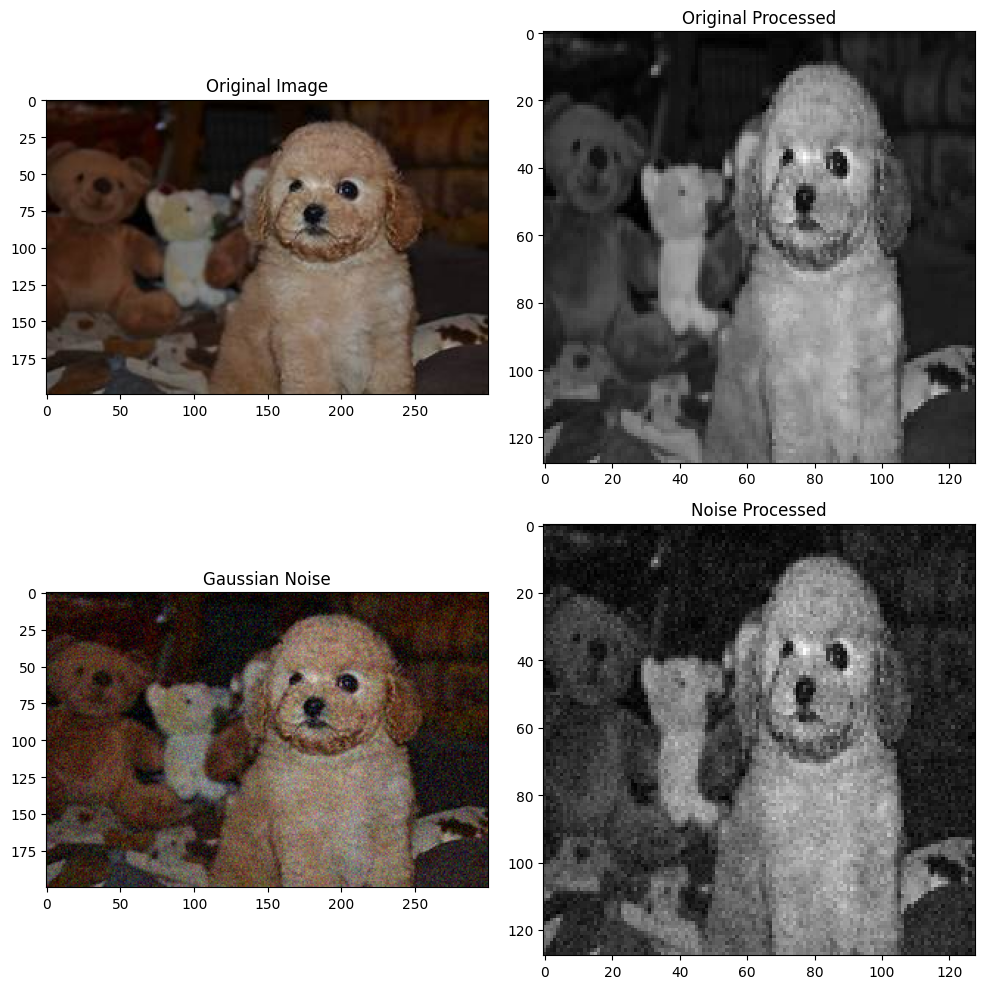

In [6]:
# Hiển thị
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

# Ảnh gốc
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("on")

# Ảnh gốc sau preprocessing
axes[0, 1].imshow(processed_original, cmap="gray")
axes[0, 1].set_title("Original Processed")
axes[0, 1].axis("on")

# Ảnh đã thêm noise
axes[1, 0].imshow(noise_image)
axes[1, 0].set_title("Gaussian Noise")
axes[1, 0].axis("on")

# Ảnh noise sau preprocessing
axes[1, 1].imshow(processed_noise, cmap="gray")
axes[1, 1].set_title("Noise Processed")
axes[1, 1].axis("on")

plt.tight_layout()
plt.show()

---
## 3. Wavelet Hash Generation
---

### 3.1 Wavelet Transform

Ảnh sau khi tiền xử lý được phân rã bằng Biến đổi Wavelet rời rạc hai chiều (2D DWT). 


Kết quả thu được gồm các hệ số xấp xỉ (Approximation) và các hệ số chi tiết theo phương ngang, dọc và chéo ở nhiều mức phân rã.

In [7]:
def wavelet_transform(image_path, wavelet="haar", level=4):
    """
    Reads an image, preprocesses it, and performs 2D Discrete Wavelet Decomposition.
    
    Parameters:
    - image_path (str): Path to the input image file.
    - wavelet (str): Name of the wavelet family to use (default is 'haar').
    - level (int): Decomposition level (default is 4).
        
    Returns:
    - list: Coefficients list [cA_n, (cH_n, cV_n, cD_n), ..., (cH_1, cV_1, cD_1)].
    """
    # Read image from path
    img = cv2.imread(image_path)

    # Resize and normalize image
    processed_img = preprocess_image(
        image=img,
        image_size=128,
        remove_background=False
    )

    # Perform multi-level 2D Discrete Wavelet Transform
    coeffs = pywt.wavedec2(
        data=processed_img,
        wavelet=wavelet,
        level=level,
    )

    return coeffs

### 3.2 Quantization
Các hệ số Wavelet được lượng tử hóa bằng cách chia cho một bước lượng tử (step) rồi làm tròn.

Việc này giúp giảm ảnh hưởng của nhiễu nhỏ và tăng tính ổn định của hàm băm.

In [8]:
def quantize_coefficients(coeffs, step=2):
    """
    Quantize multi-level wavelet coefficients using a uniform scalar step size.

    Args:
        coeffs (list): Multi-level wavelet coefficients from 'pywt.wavedec2'.
        step (int or float, optional): Quantization step size. Defaults to 2.

    Returns:
        list: Quantized coefficients with the exact same structure as input.
    """
    # Helper function for coefficient quantization
    def quantize_element(c, step=2):
        if isinstance(c, tuple):
            return tuple(np.round(a=arr / step) for arr in c)
        return np.round(a=c / step)

    # Quantize coefficients level by level
    quantized_coeffs = [
        quantize_element(c=c, step=step)
        for c in coeffs
    ]
    
    return quantized_coeffs

### 3.3 Hash Generation
Sau khi lượng tử hóa, toàn bộ hệ số được nối thành một vector một chiều.

Giá trị trung vị (median) của vector được sử dụng làm ngưỡng để sinh mã băm: hệ số lớn hơn median được gán bit 1, ngược lại gán bit 0.

In [9]:
def generate_hash(quantized_coeffs):
    # Chỉ lấy cA
    cA = quantized_coeffs[0]

    flattened = cA.flatten()

    median = np.median(flattened)
    hash_code = (flattened > median).astype(np.uint8)

    return hash_code.tolist()

---

In [10]:
def wavelet_hash(image_path, wavelet="haar", level=4, step=2):
    """
    Generate a binary hash from an image by pipeline calling DWT, quantization, and hashing.

    Args:
        image_path (str): Path to the input image file.
        wavelet (str, optional): Wavelet type for decomposition. Defaults to "haar".
        level (int, optional): Decomposition level. Defaults to 4.
        step (int or float, optional): Quantization step size. Defaults to 2.

    Returns:
        list: A 1D list of binary integers (0 or 1) representing the image hash.
    """
    # Step 1: Perform 2D Discrete Wavelet Transform
    coeffs = wavelet_transform(image_path=image_path, wavelet=wavelet, level=level)
    
    # Step 2: Quantize the extracted coefficients
    quantized_coeffs = quantize_coefficients(coeffs=coeffs, step=step)
    
    # Step 3: Flatten and convert to final binary hash code
    hash_code = generate_hash(quantized_coeffs=quantized_coeffs)
    
    return hash_code

---
## 4. Hash Comparison
---

In [11]:
# Tính khoảng cách Hamming
def hamming_distance(hash1, hash2):
    if len(hash1) != len(hash2):
        raise ValueError("Binary strings must be equal length")
    return sum(c1 != c2 for c1, c2 in zip(hash1, hash2))

#### Example: Same Subject with Different Transformations

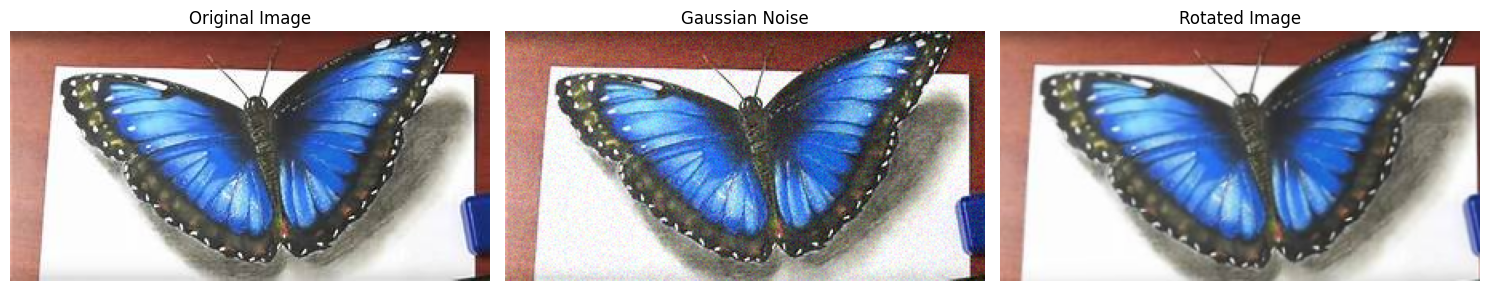

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Original Image
axes[0].imshow(cv2.cvtColor(cv2.imread('../assets/Animals-10/original/Butterfly_7.png'), cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

# Plot Noisy Image
axes[1].imshow(cv2.cvtColor(cv2.imread('../assets/Animals-10/noise/Butterfly_7_noise.png'), cv2.COLOR_BGR2RGB))
axes[1].set_title("Gaussian Noise")
axes[1].axis("off")

# Plot Rotated Image
axes[2].imshow(cv2.cvtColor(cv2.imread('../assets/Animals-10/rotate/Butterfly_7_rotate.png'), cv2.COLOR_BGR2RGB))
axes[2].set_title("Rotated Image")
axes[2].axis("off")

# Adjust spacing and display
plt.tight_layout()
plt.show()

In [13]:
# Read image -> Wavelet transform -> Quantization -> Generation hash
hash1 = wavelet_hash('../assets/Animals-10/original/Butterfly_7.png')
# hash2 = wavelet_hash('../assets/Animals-10/noise/Butterfly_7_noise.png')
hash2 = wavelet_hash('../assets/Animals-10/rotate/Butterfly_7_rotate.png')

# Calculate Hamming distance
hamming = hamming_distance(hash1, hash2) 
total_bits = len(hash1)
similarity = (1 - hamming / total_bits) * 100   # tỷ lệ giống nhau

print(f"Tổng số bit của mã hash: {total_bits} bit")
print(f"Khoảng cách Hamming: {hamming}")
print(f"Tỷ lệ giống nhau: {similarity:.2f}%")
print(f"Tỷ lệ khác biệt: {100-similarity:.2f}%")

Tổng số bit của mã hash: 64 bit
Khoảng cách Hamming: 2
Tỷ lệ giống nhau: 96.88%
Tỷ lệ khác biệt: 3.12%


#### Example: Different Subjects

In [14]:
hash2 = wavelet_hash('../assets/Animals-10/original/Sheep_1.png')
hash1 = wavelet_hash('../assets/Animals-10/original/Squirrel_7.png')

# Calculate Hamming distance
hamming = hamming_distance(hash1, hash2) 
total_bits = len(hash1)

similarity = (1 - hamming / total_bits) * 100   # tỷ lệ giống nhau
difference = (hamming / total_bits) * 100       # tỷ lệ khác nhau

print(f"Tổng số bit của mã hash: {total_bits} bit")
print(f"Khoảng cách Hamming: {hamming}")
print(f"Tỷ lệ giống nhau: {similarity:.2f}%")
print(f"Tỷ lệ khác biệt: {difference:.2f}%")

Tổng số bit của mã hash: 64 bit
Khoảng cách Hamming: 38
Tỷ lệ giống nhau: 40.62%
Tỷ lệ khác biệt: 59.38%


---
## 5. Performance Evaluation
---

In [15]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

In [16]:
def compute_distances(df, wavelet="haar"):
    """Tính Hamming distance cho toàn bộ pairs với 1 loại wavelet."""
    y_true, y_score = [], []
    for _, row in df.iterrows():
        hash1 = wavelet_hash('../' + row["image_1"], wavelet=wavelet)
        hash2 = wavelet_hash('../' + row["image_2"], wavelet=wavelet)
        if hash1 is None or hash2 is None:
            continue
        y_true.append(row["label"])
        y_score.append(hamming_distance(hash1, hash2))
    return y_true, y_score


def evaluate_at_threshold(y_true, y_score, threshold):
    """Evaluate metrics at a specific threshold."""
    y_pred = [1 if d <= threshold else 0 for d in y_score]
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }


def find_best_threshold(y_true, y_score):
    """Tìm threshold tối ưu dựa trên Youden's index (TPR - FPR)."""
    similarity_score = [-d for d in y_score]
    fpr, tpr, thresholds = roc_curve(y_true=y_true, y_score=similarity_score)
    best_idx = np.argmax(tpr - fpr)
    best_similarity_threshold = thresholds[best_idx]
    best_distance_threshold = -best_similarity_threshold
    
    # Evaluate F1 at optimal threshold
    y_pred = [1 if d <= best_distance_threshold else 0 for d in y_score]
    best_f1 = f1_score(y_true=y_true, y_pred=y_pred)
    
    return best_distance_threshold, best_f1

In [17]:
# Load dataset
df = pd.read_csv("../assets/image_pairs.csv")
df.head()

,image_1,image_2,transform,label
0,assets/Animals-10/original/Butterfly_1.png,assets/Animals-10/noise/Butterfly_1_noise.png,gaussian_noise,1
1,assets/Animals-10/original/Butterfly_1.png,assets/Animals-10/rotate/Butterfly_1_rotate.png,rotation,1
2,assets/Animals-10/original/Butterfly_1.png,assets/Animals-10/original/Spider_2.png,different_original,0
3,assets/Animals-10/original/Butterfly_1.png,assets/Animals-10/noise/Spider_2_noise.png,different_noise,0
4,assets/Animals-10/original/Butterfly_1.png,assets/Animals-10/rotate/Spider_2_rotate.png,different_rotation,0


In [18]:
# Compute distances cho wavelet mặc định
y_true, y_score = compute_distances(df, wavelet="haar")
print(f"Số cặp hợp lệ: {len(y_true)} / {len(df)}")

# Evaluate tại một threshold cụ thể
metrics = evaluate_at_threshold(y_true, y_score, threshold=20)
print("\nMetrics at threshold=20:")
for name, value in metrics.items():
    print(f"{name.capitalize():<10}: {value:.4f}")

Số cặp hợp lệ: 500 / 500

Metrics at threshold=20:
Accuracy  : 0.9340
Precision : 0.8584
Recall    : 1.0000
F1        : 0.9238


### 5.1 Compute Distances and Evaluate Metrics

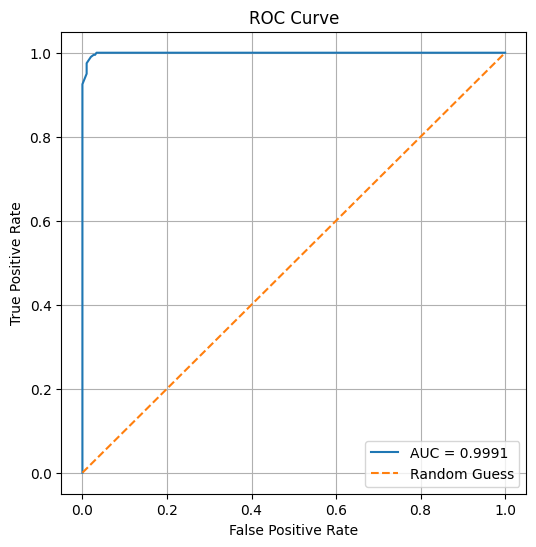

In [19]:
# Chuyển distance -> similarity (distance càng nhỏ càng giống)
similarity_score = [-d for d in y_score]

# Tính ROC và AUC
fpr, tpr, thresholds = roc_curve(
    y_true=y_true,
    y_score=similarity_score
)
roc_auc = auc(
    x=fpr,
    y=tpr
)

# Vẽ ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

### 5.2 ROC Curve Analysis

In [20]:
# Tìm threshold tối ưu
best_idx = np.argmax(tpr - fpr)

# Threshold trên similarity score
best_similarity_threshold = thresholds[best_idx]

# Quy đổi về distance threshold
best_distance_threshold = -best_similarity_threshold

print(f"Best distance threshold: {best_distance_threshold:.4f}")
print(f"TPR: {tpr[best_idx]:.4f}")
print(f"FPR: {fpr[best_idx]:.4f}")

Best distance threshold: 12.0000
TPR: 0.9900
FPR: 0.0200


### 5.3 Confusion Matrix and Performance Metrics

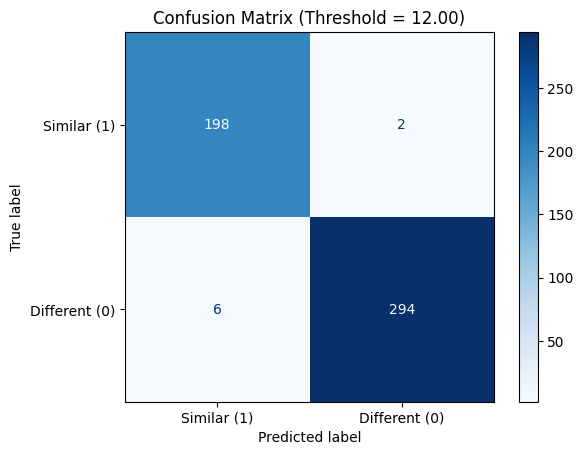

In [21]:
# Chuyển distance -> dự đoán nhị phân
y_pred = [1 if d <= best_distance_threshold else 0 for d in y_score]

cm = confusion_matrix(
    y_true=y_true,
    y_pred=y_pred,
    labels=[1, 0]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Similar (1)", "Different (0)"]
)

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {best_distance_threshold:.2f})")
plt.show()

---

---
## 6. Advanced Experiment
### 6.1 Comparison of Different Wavelets

In [22]:
wavelets_to_test = ["haar", "db2", "db4", "sym2", "coif1", "bior1.3"]

results = []
for wavelet in wavelets_to_test:
    y_true_w, y_score_w = compute_distances(df, wavelet=wavelet)
    best_t, best_f1_w = find_best_threshold(y_true_w, y_score_w)
    metrics_w = evaluate_at_threshold(y_true_w, y_score_w, threshold=best_t)
    results.append({
        "wavelet": wavelet,
        "best_threshold": best_t,
        **metrics_w,
    })

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df

,wavelet,best_threshold,accuracy,precision,recall,f1
0,db2,26.0,0.988,0.975490,0.995,0.985149
1,sym2,26.0,0.988,0.975490,0.995,0.985149
2,haar,12.0,0.984,0.970588,0.990,0.980198
3,coif1,44.0,0.982,0.965854,0.990,0.977778
4,bior1.3,43.0,0.980,0.961165,0.990,0.975369
5,db4,43.0,0.956,0.963542,0.925,0.943878


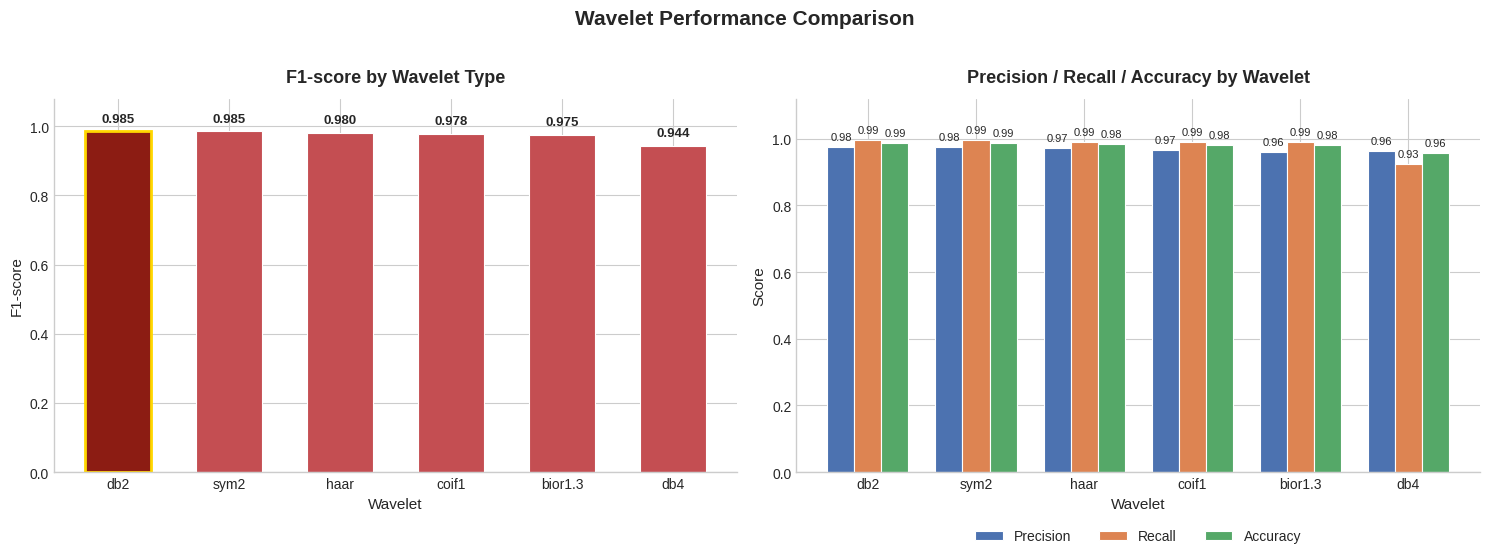

In [23]:
plt.style.use("seaborn-v0_8-whitegrid")

colors = {
    "precision": "#4C72B0",
    "recall": "#DD8452",
    "accuracy": "#55A868",
    "f1": "#C44E52",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Chart 1: F1-score by wavelet ---
bars = axes[0].bar(
    results_df["wavelet"], results_df["f1"],
    color=colors["f1"], edgecolor="white", linewidth=0.8, width=0.6
)
axes[0].set_title("F1-score by Wavelet Type", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Wavelet", fontsize=11)
axes[0].set_ylabel("F1-score", fontsize=11)
axes[0].set_ylim(0, 1.08)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].tick_params(axis="x", rotation=0)

for bar, v in zip(bars, results_df["f1"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, v + 0.02,
        f"{v:.3f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold"
    )

# Highlight best F1
best_idx = results_df["f1"].idxmax()
bars[best_idx].set_color("#8C1C13")
bars[best_idx].set_edgecolor("gold")
bars[best_idx].set_linewidth(2)

# --- Chart 2: Grouped Precision / Recall / Accuracy ---
metrics = ["precision", "recall", "accuracy"]
x = np.arange(len(results_df))
width = 0.25

for i, m in enumerate(metrics):
    offset = (i - 1) * width
    bars_g = axes[1].bar(
        x + offset, results_df[m], width,
        label=m.capitalize(), color=colors[m],
        edgecolor="white", linewidth=0.8
    )
    for bar, v in zip(bars_g, results_df[m]):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2, v + 0.015,
            f"{v:.2f}", ha="center", va="bottom", fontsize=8
        )

axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df["wavelet"])
axes[1].set_title("Precision / Recall / Accuracy by Wavelet", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Wavelet", fontsize=11)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_ylim(0, 1.12)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Wavelet Performance Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Image Retrieval Demo

In [24]:
def find_most_similar_image(input_image_path, search_dir="../assets/Animals-10/original", wavelet="haar", level=4, step=2):
    """
    Tìm ảnh giống nhất trong thư mục search_dir so với ảnh đầu vào
    bằng cách so sánh Hamming distance giữa các wavelet hash.
    """
    input_path = Path(input_image_path)
    if not input_path.exists():
        raise FileNotFoundError(f"Input image not found: {input_image_path}")

    search_path = Path(search_dir)
    if not search_path.exists():
        raise FileNotFoundError(f"Search folder not found: {search_dir}")

    input_hash = wavelet_hash(str(input_path), wavelet=wavelet, level=level, step=step)

    best_match = None
    best_distance = None

    for candidate_path in sorted(search_path.glob("*")):
        if candidate_path.is_file() and candidate_path.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tiff"}:
            if candidate_path == input_path:
                continue

            candidate_hash = wavelet_hash(str(candidate_path), wavelet=wavelet, level=level, step=step)
            distance = hamming_distance(input_hash, candidate_hash)

            if best_distance is None or distance < best_distance:
                best_distance = distance
                best_match = candidate_path

    return best_match, best_distance

In [25]:
best_match, best_distance = find_most_similar_image('../assets/Animals-10//rotate/Butterfly_6_rotate.png')

In [26]:
best_match

PosixPath('../assets/Animals-10/original/Butterfly_6.png')

In [27]:
best_distance

4